In [286]:
# Titanic Survival Prediction

## Problem Statement

# The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, family size, and other characteristics.

# This project includes:

# - Data Cleaning
# - Exploratory Data Analysis
# - Feature Engineering
# - Machine Learning
# - Hyperparameter Tuning
# - Model Evaluation
# - Explainable AI
# - Deployment using Streamlit

In [287]:
# Notebook 1 : Problem Statement & Data Loading

# This notebook will contain:

# Import Libraries
# Load Dataset
# Dataset Overview
# Initial Observations

In [288]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Options
pd.set_option('display.max_columns', None)

# Plot Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")


# pandas :- Used to load and manipulate tabular data.

# numpy :- Used for numerical computations.

# matplotlib :- Used to create graphs.

# seaborn :- Used to create attractive statistical visualizations.

# warnings.filterwarnings() :- Hides unnecessary warning messages.

# pd.set_option() :- Displays all columns when viewing a DataFrame.

Libraries Imported Successfully!


In [289]:
# Load the Dataset

df = pd.read_csv("Titanic-Dataset.csv")

# This is used to Reads a CSV file and Stores it in a Dataframe named df. 

In [290]:
# Display the First 5 Rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [291]:
# Check Dataset Shape

df.shape

# It explain rows and columns

(891, 12)

In [292]:
# Display Column Names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [293]:
# Dataset Information

df.info()

# It provides numbers of rows , columnns , data type , missing values , memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [294]:
# Statistical Summary

df.describe()

# It shows numerical columns like mean , median(50%) , standard deviation , minimum , maximum , quartiles (25% , 50% , 75%)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [295]:
# Check Missing Values

df.isnull().sum()

# This is used to counts the missing values in each columns.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [296]:
# Check Duplicate Rows

df.duplicated().sum()

# This is uesd to counts the duplicates values in our data

np.int64(0)

In [297]:
## Initial Observations

# - Dataset contains 891 passenger records.
# - There are 12 columns.
# - Age contains missing values.
# - Cabin has a large number of missing values.
# - Embarked contains a few missing values.
# - There are numerical and categorical features.
# - Target variable is "Survived".

In [298]:
# Notebook 2: Data Understanding & Exploratory Data Analysis (EDA)

# In this notebook, we will:

# Understand each feature
# Explore the target variable (Survived)
# Analyze numerical and categorical features
# Identify relationships between variables
# Draw conclusions from the data

In [299]:
# Display Sample Data

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [300]:
# Understand the Features

# # Feature Description

# PassengerId : Unique Passenger ID

# Survived :
# 0 = Did Not Survive
# 1 = Survived

# Pclass :
# 1 = First Class
# 2 = Second Class
# 3 = Third Class

# Name : Passenger Name

# Sex : Gender

# Age : Passenger Age

# SibSp : Number of Siblings/Spouses

# Parch : Number of Parents/Children

# Ticket : Ticket Number

# Fare : Ticket Fare

# Cabin : Cabin Number

# Embarked :
# S = Southampton
# C = Cherbourg
# Q = Queenstown

In [301]:
# Target Variable Distribution

df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

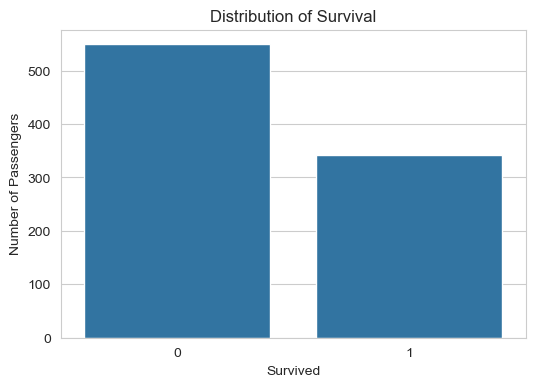

In [302]:
# For Better Visualization

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Survived")

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

In [303]:
# Percentage of Survivors

survival_percentage = df["Survived"].value_counts(normalize=True)*100

print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [304]:
# Numerical Features

numerical_features = df.select_dtypes(include=['int64','float64'])

numerical_features.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [305]:
# Categorical Features

categorical_features = df.select_dtypes(include=['object'])
categorical_features.columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

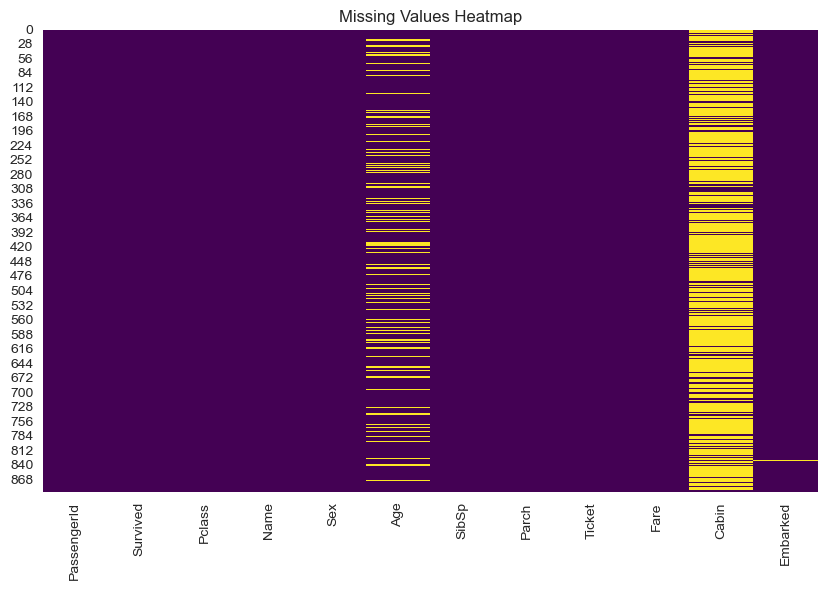

In [306]:
# Missing Value Visualization

plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

# You can visually identify:

# Age has missing values
# Cabin has many missing values
# Embarked has a few missing values

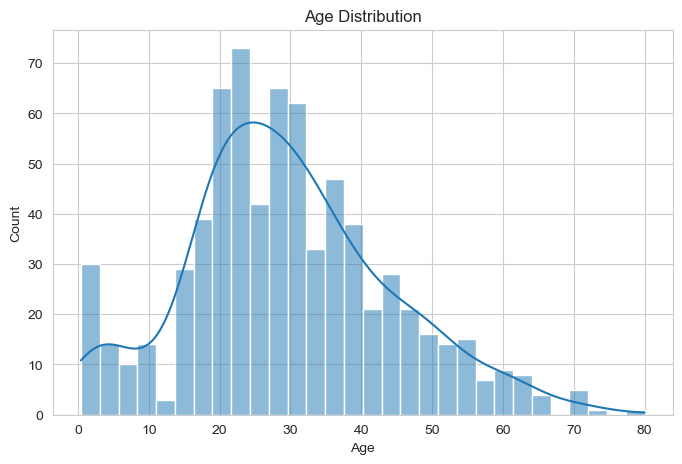

In [307]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Age"],
             bins=30,
             kde=True)

plt.title("Age Distribution")

plt.show()

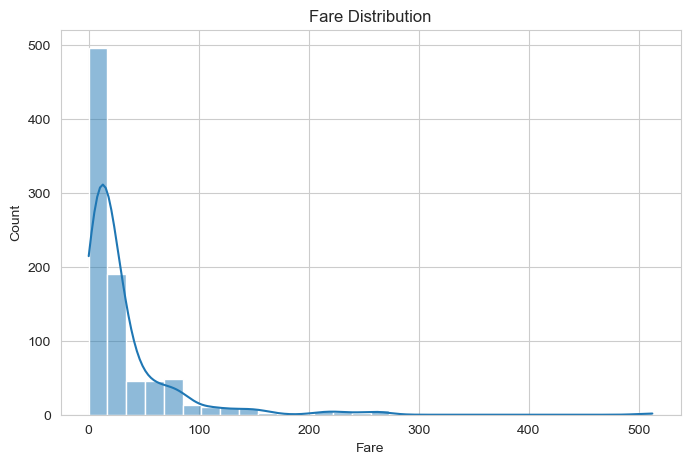

In [308]:
# Fare Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Fare"],
             bins=30,
             kde=True)

plt.title("Fare Distribution")

plt.show()

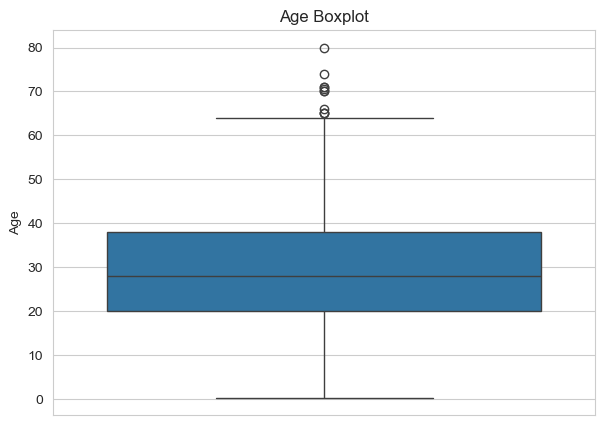

In [309]:
# Boxplot (Age)

plt.figure(figsize=(7,5))

sns.boxplot(y=df["Age"])

plt.title("Age Boxplot")

plt.show()

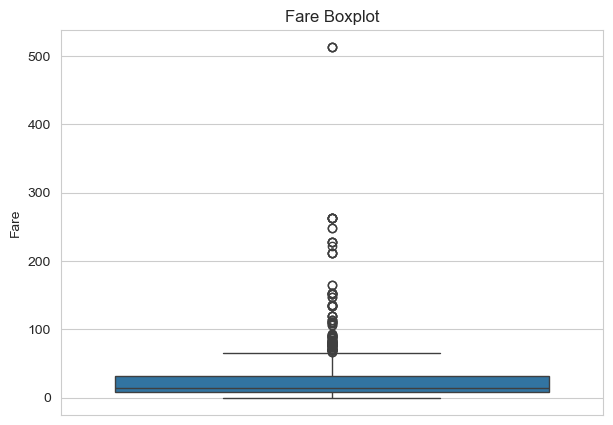

In [310]:
# Boxplot (Fare)

plt.figure(figsize=(7,5))

sns.boxplot(y=df["Fare"])

plt.title("Fare Boxplot")

plt.show()

In [311]:
# Correlation Matrix

corr = df.corr(numeric_only=True)

corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


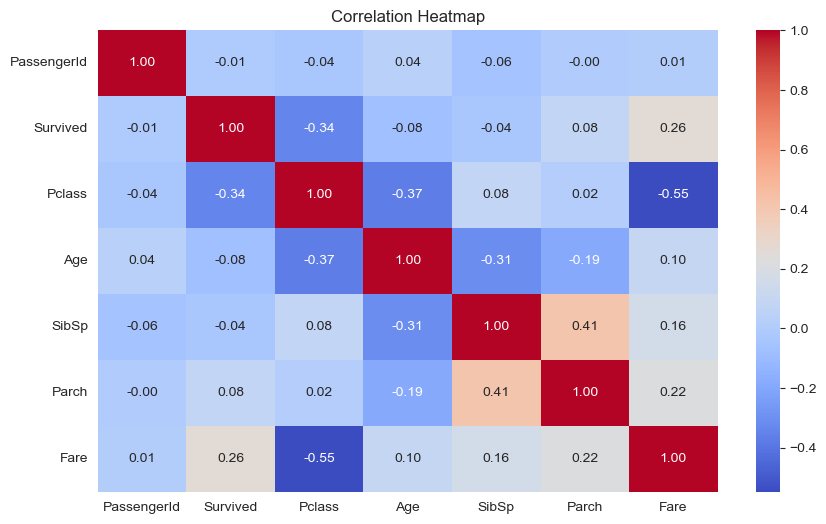

In [312]:
# Correlation Heatmap

corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [313]:
# Summary

# 1. Dataset contains both numerical and categorical features.

# 2. Cabin has a large number of missing values.

# 3. Age contains missing values.

# 4. Fare distribution is right-skewed.

# 5. Most passengers belong to the age group 20–40 years.

# 6. Survival rate is approximately 38%.

# 7. Outliers are present in Fare.

In [314]:
# Notebook 03: Univariate & Bivariate Analysis

# In this notebook, we will answer questions like:

# Does gender affect survival?
# Does passenger class affect survival?
# Are children more likely to survive?
# Does fare influence survival?
# Does family size matter?
# Does embarkation port affect survival?

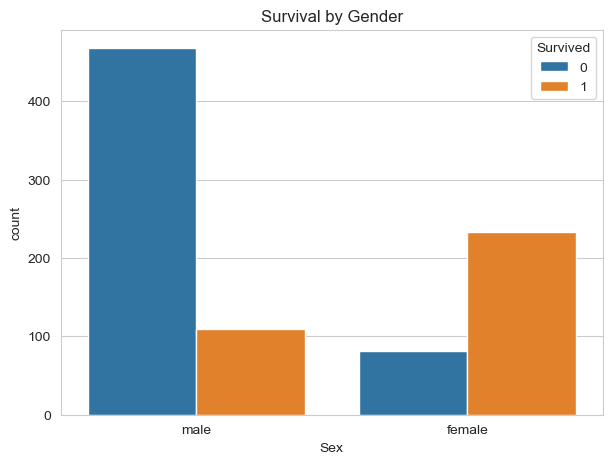

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [315]:
# Survival by Gender

# Count plot

plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Sex",
              hue="Survived")

plt.title("Survival by Gender")
plt.show()

# Survival Percentage

gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
)*100

gender_survival


## Observation

# Female passengers had a much higher survival rate than male passengers.

# This suggests that gender is one of the strongest predictors of survival.

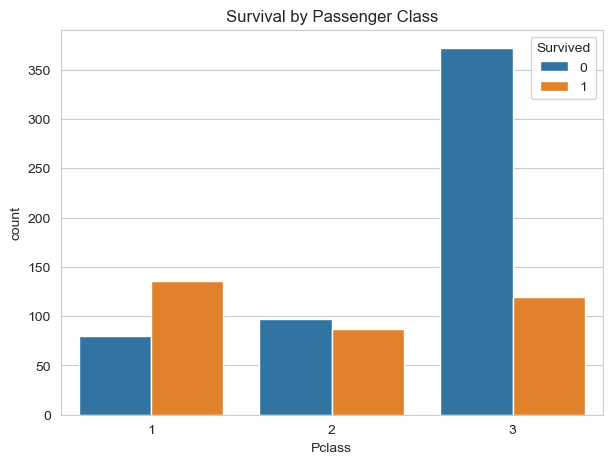

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [316]:
# Survival by Passenger Class


import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")

plt.show()

# Percentage

pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
)*100


# Passengers in First Class had the highest survival rate.

# Third Class passengers had the lowest survival rate.

# Passenger class significantly influenced survival.

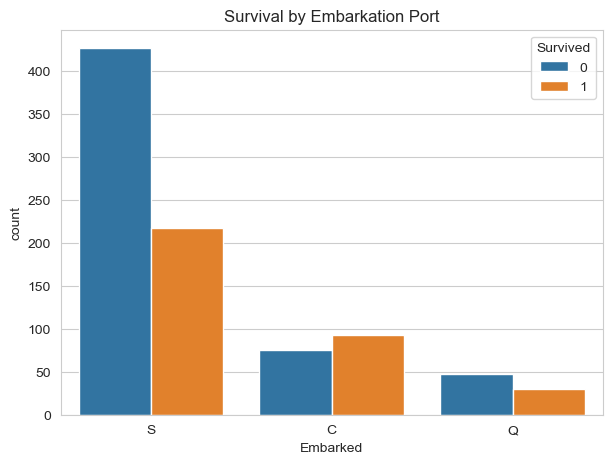

In [317]:
# Survival by Embarked

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived"
)

plt.title("Survival by Embarkation Port")

plt.show()


# Passengers embarking from different ports showed different survival rates.

# This suggests that embarkation location may have some influence on survival.

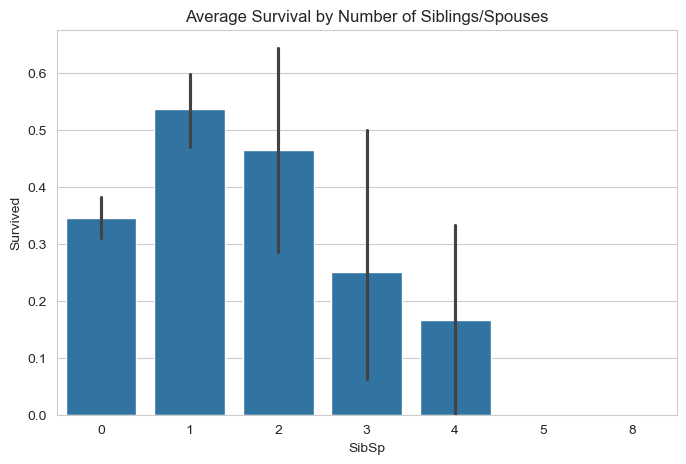

In [318]:
# Survival by SibSp

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="SibSp",
    y="Survived"
)

plt.title("Average Survival by Number of Siblings/Spouses")

plt.show()


# Passengers with one or two siblings/spouses tended to survive more often than those traveling alone or in very large families.

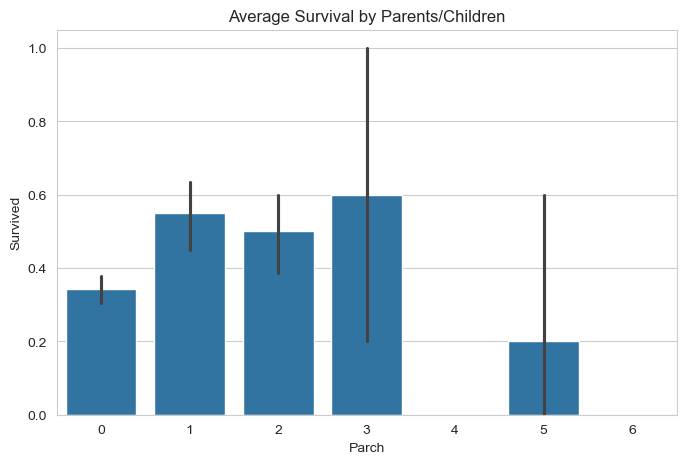

In [319]:
# Survival by Parch

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Parch",
    y="Survived"
)

plt.title("Average Survival by Parents/Children")

plt.show()

# Passengers with small families generally had better survival rates than those with very large families.

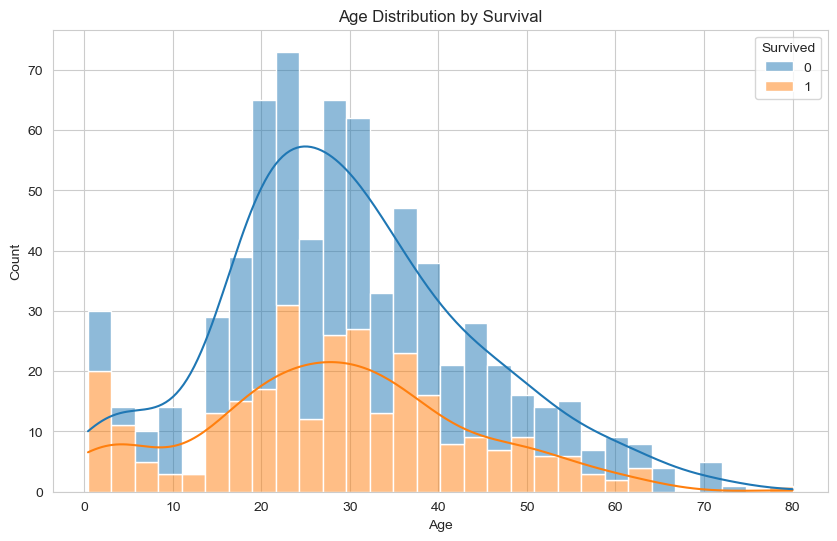

In [320]:
# Survival by Age

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Survival")

plt.show()

# Younger passengers generally had a higher survival rate.

# Many adult passengers did not survive.

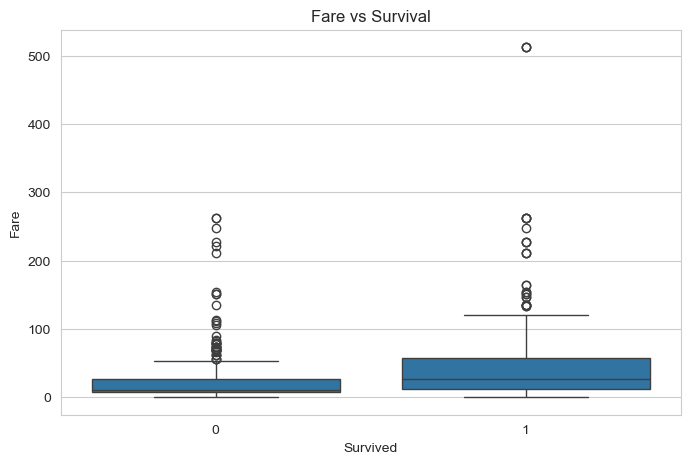

In [321]:
# Survival by Fare

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare vs Survival")

plt.show()


# Passengers who paid higher fares were more likely to survive.

# This indicates that ticket fare may be an important predictor.

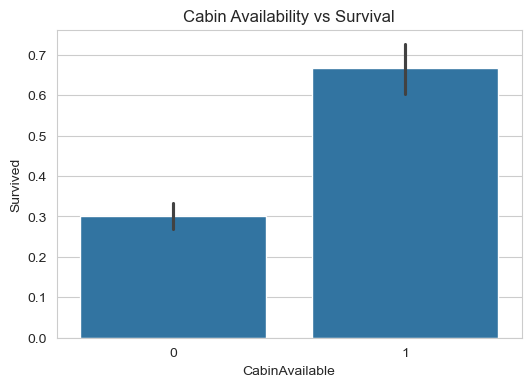

In [322]:
# Survival by Cabin Availability

df["CabinAvailable"] = df["Cabin"].notnull().astype(int)

plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="CabinAvailable",
    y="Survived"
)

plt.title("Cabin Availability vs Survival")

plt.show()


# Passengers with recorded cabin information generally had a higher survival rate.

# This may indicate that they were wealthier passengers.

In [323]:
# Create Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp","Parch","FamilySize"]].head()



,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


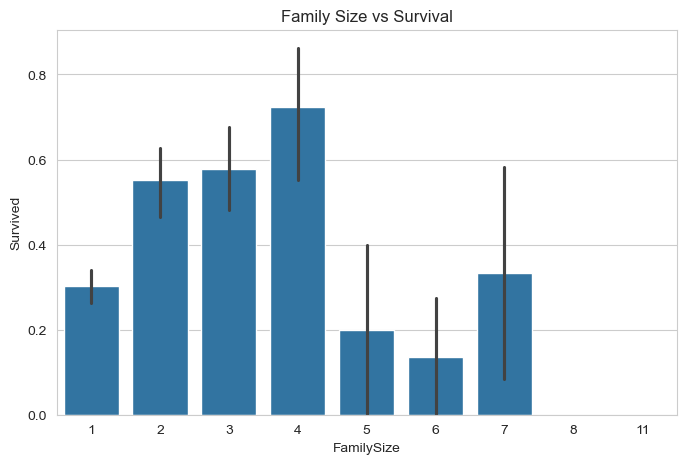

In [324]:
# Survival by Family Size

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)

plt.title("Family Size vs Survival")

plt.show()

# Passengers traveling in small families had the highest survival rate.

# Very large families had lower survival rates.

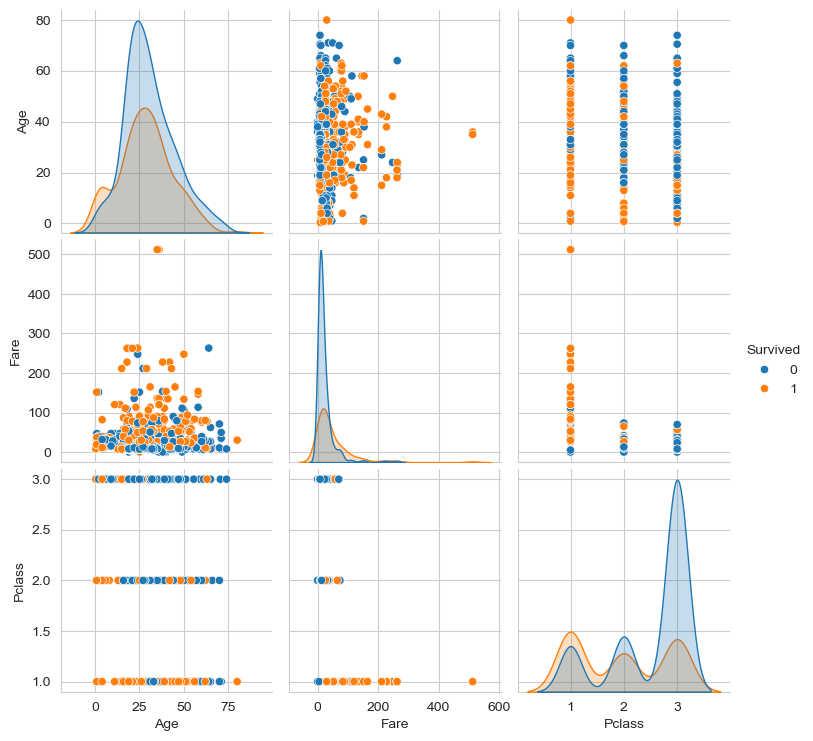

In [325]:
# Pairplot


sns.pairplot(
    df[["Age","Fare","Pclass","Survived"]],
    hue="Survived"
)

plt.show()

# This visualizes pairwise relationships between important numerical features and can reveal clusters or patterns.

In [326]:
# Key Insights :-

# 1. Female passengers had significantly higher survival rates.

# 2. First-class passengers survived more often than second- and third-class passengers.

# 3. Children tended to survive more often than older passengers.

# 4. Higher ticket fares were associated with higher survival.

# 5. Small families had better survival rates.

# 6. Cabin availability correlated with increased survival.

# 7. Gender, Passenger Class, Fare, Age, and Family Size appear to be the strongest predictors of survival.


In [327]:
# Notebook 04: Data Cleaning & Feature Engineering

# In this notebook, we will:

# Handle missing values
# Create new useful features
# Remove unnecessary columns
# Encode categorical variables
# Prepare the dataset for machine learning

In [328]:
pd.set_option("display.max_columns", None)

In [329]:
# Check Missing Values Again

df.isnull().sum()

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
CabinAvailable      0
FamilySize          0
dtype: int64

In [330]:
# Handle Missing Values in Age

df["Age"].fillna(df["Age"].median(), inplace=True)

# The Age column contains outliers, so the median is more robust than the mean.
# verify

df['Age'].isnull().sum()

np.int64(0)

In [331]:
# Handle Missing Values in Embarked

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Embarked is a categorical feature, so we replace missing values with the most frequent category.
# verify

df["Embarked"].isnull().sum()

np.int64(0)

In [332]:
# Handle Cabin

# Check how many values are missing.

df["Cabin"].isnull().sum()

# Since most values are missing, don't drop the information entirely. Instead, create a feature indicating whether cabin information is available.

df["CabinAvailable"] = df["Cabin"].notnull().astype(int)

# check

df[["Cabin", "CabinAvailable"]].head()

# now remove the original columns 

df.drop("Cabin", axis=1, inplace=True)

In [333]:
# Create Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# check

df[["SibSp", "Parch", "FamilySize"]].head()

Why?

# A passenger traveling with family may have had a different survival chance than someone traveling alone

Object `Why` not found.


In [334]:
# Create IsAlone

df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

# check

df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [335]:
# Extract Passenger Title
# Passenger names contain titles like Mr, Mrs, Miss, Master.

df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# check

df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [336]:
# Group Rare Titles

df["Title"] = df["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr",
     "Major","Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

df["Title"] = df["Title"].replace("Mlle","Miss")
df["Title"] = df["Title"].replace("Ms","Miss")
df["Title"] = df["Title"].replace("Mme","Mrs")

# check

df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [337]:
# Create Age Groups

bins = [0, 12, 18, 35, 60, 100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)


# check

df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


In [338]:
# Create Fare Groups

df["FareGroup"] = pd.qcut(
    df["Fare"],
    4,
    labels=["Low","Medium","High","Very High"]
)

# check

df[["Fare","FareGroup"]].head()

,Fare,FareGroup
0,7.2500,Low
1,71.2833,Very High
2,7.9250,Medium
3,53.1000,Very High
4,8.0500,Medium


In [339]:
# Unnecessary Columns
# These columns are not directly useful for prediction after extracting relevant information:

df.drop(
    ["PassengerId", "Name", "Ticket"],
    axis=1,
    inplace=True
)

# check

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,0,3,male,22.0,1,0,7.2500,S,0,2,0,Mr,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,1,2,0,Mrs,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,0,1,1,Miss,Young Adult,Medium
3,1,1,female,35.0,1,0,53.1000,S,1,2,0,Mrs,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,0,1,1,Mr,Young Adult,Medium


In [340]:
# Check Data Types

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    int64   
 2   Sex             891 non-null    object  
 3   Age             891 non-null    float64 
 4   SibSp           891 non-null    int64   
 5   Parch           891 non-null    int64   
 6   Fare            891 non-null    float64 
 7   Embarked        891 non-null    object  
 8   CabinAvailable  891 non-null    int64   
 9   FamilySize      891 non-null    int64   
 10  IsAlone         891 non-null    int64   
 11  Title           891 non-null    object  
 12  AgeGroup        891 non-null    category
 13  FareGroup       891 non-null    category
dtypes: category(2), float64(2), int64(7), object(3)
memory usage: 85.8+ KB


In [341]:
# Summary

# - Filled missing values in Age using the median.
# - Filled missing values in Embarked using the mode.
# - Created CabinAvailable feature.
# - Created FamilySize feature.
# - Created IsAlone feature.
# - Extracted passenger titles.
# - Grouped rare titles.
# - Created AgeGroup and FareGroup.
# - Removed unnecessary columns.
# - Saved the cleaned dataset.

In [342]:
# Notebook 05: Data Preprocessing

# In this notebook, we will:

# Load the cleaned dataset
# Encode categorical features
# Split Features (X) and Target (y)
# Train-Test Split
# Scale numerical features
# Save preprocessed data

In [343]:
# import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [344]:
# Check Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    int64   
 2   Sex             891 non-null    object  
 3   Age             891 non-null    float64 
 4   SibSp           891 non-null    int64   
 5   Parch           891 non-null    int64   
 6   Fare            891 non-null    float64 
 7   Embarked        891 non-null    object  
 8   CabinAvailable  891 non-null    int64   
 9   FamilySize      891 non-null    int64   
 10  IsAlone         891 non-null    int64   
 11  Title           891 non-null    object  
 12  AgeGroup        891 non-null    category
 13  FareGroup       891 non-null    category
dtypes: category(2), float64(2), int64(7), object(3)
memory usage: 85.8+ KB


In [345]:
# Identify Categorical Columns

categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

# Now check the dataset

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,0,3,male,22.0,1,0,7.2500,S,0,2,0,Mr,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,1,2,0,Mrs,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,0,1,1,Miss,Young Adult,Medium
3,1,1,female,35.0,1,0,53.1000,S,1,2,0,Mrs,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,0,1,1,Mr,Young Adult,Medium


In [346]:
# Separate Features and Target

# for target variable

y = df["Survived"]

# features

X = df.drop("Survived", axis=1)

In [347]:
# Check Shapes

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (891, 13)
Target Shape : (891,)


In [348]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Why train_test_split?

# We train the model using 80% of the data.

# We test it using 20%.

# This allows us to evaluate performance on unseen data.

In [349]:
# Check Shapes

print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(712, 13)
(179, 13)
(712,)
(179,)


In [350]:
# Identify Numerical Features

X_train.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'CabinAvailable', 'FamilySize', 'IsAlone', 'Title', 'AgeGroup',
       'FareGroup'],
      dtype='object')

In [351]:
# Scale Numerical Features

scaler = StandardScaler()

numerical_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize"
]

# Fit only on the training data:

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

# Transform the test data using the same scaler:

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)



# Why only fit on training data?

# If you fit the scaler on the entire dataset, information from the test set leaks into the training process.

# This is called Data Leakage, and it leads to overly optimistic performance estimates.

In [352]:
# Check Scaled Data

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable,FamilySize,IsAlone,Title,AgeGroup,FareGroup
692,3,male,-0.112078,-0.465084,-0.466183,0.513812,S,0,-0.556339,1,Mr,Young Adult,Very High
481,2,male,-0.112078,-0.465084,-0.466183,-0.662563,S,0,-0.556339,1,Mr,Young Adult,Low
527,1,male,-0.112078,-0.465084,-0.466183,3.955399,S,1,-0.556339,1,Mr,Young Adult,Very High
855,3,female,-0.879807,-0.465084,0.727782,-0.467874,S,0,0.073412,0,Mrs,Teen,Medium
801,2,female,0.118241,0.478335,0.727782,-0.115977,S,0,0.703162,0,Mrs,Young Adult,High


In [353]:
# Verify Missing Values

X_train.isnull().sum()

Pclass            0
Sex               0
Age               0
SibSp             0
Parch             0
Fare              0
Embarked          0
CabinAvailable    0
FamilySize        0
IsAlone           0
Title             0
AgeGroup          0
FareGroup         0
dtype: int64

In [354]:
# Save Train/Test Sets (Optional but Recommended)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# This allows you to reuse them without repeating preprocessing.

In [355]:
# Summary

# - Loaded cleaned dataset
# - Encoded categorical features
# - Separated features and target
# - Performed train-test split
# - Scaled numerical features
# - Checked for missing values
# - Saved preprocessed datasets

In [356]:
# Notebook 06: Model Building & Model Comparison

# In this notebook, we will:

# Load the preprocessed dataset
# Train multiple machine learning models
# Evaluate them using multiple metrics
# Use Cross Validation
# Compare all models
# Select the best model

In [357]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [358]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

In [359]:
# Check which columns are still text

print(df.select_dtypes(include=['object']).columns)

Index(['Sex', 'Embarked', 'Title'], dtype='object')


In [360]:
# Encode all categorical columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ["Sex", "Embarked", "Title", "AgeGroup", "FareGroup"]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [361]:
# check

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinAvailable,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,0,3,1,22.0,1,0,7.2500,2,0,2,0,2,4,1
1,1,1,0,38.0,1,0,71.2833,0,1,2,0,3,0,3
2,1,3,0,26.0,0,0,7.9250,2,0,1,1,1,4,2
3,1,1,0,35.0,1,0,53.1000,2,1,2,0,3,4,3
4,0,3,1,35.0,0,0,8.0500,2,0,1,1,2,4,2


In [362]:
# verify

print(df.dtypes)

Survived            int64
Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Embarked            int64
CabinAvailable      int64
FamilySize          int64
IsAlone             int64
Title               int64
AgeGroup            int64
FareGroup           int64
dtype: object


In [363]:
# Separate Features and Target

# for target variable

y = df["Survived"]

# features

X = df.drop("Survived", axis=1)

# Train-Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [364]:
# Create Dictionary of Models

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Support Vector Machine": SVC(probability=True),

    "Naive Bayes": GaussianNB()

}

In [365]:
# Train Every Model

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [366]:
# Create Comparison Table

comparison = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.761194,0.739130,0.750000
1,Decision Tree,0.765363,0.684932,0.724638,0.704225
2,Random Forest,0.793296,0.728571,0.739130,0.733813
3,Gradient Boosting,0.793296,0.785714,0.637681,0.704000
4,Extra Trees,0.787709,0.718310,0.739130,0.728571
5,AdaBoost,0.787709,0.724638,0.724638,0.724638
6,KNN,0.675978,0.593220,0.507246,0.546875
7,Support Vector Machine,0.625698,0.533333,0.231884,0.323232
8,Naive Bayes,0.782123,0.697368,0.768116,0.731034


In [367]:
# Sort Results

comparison.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.761194,0.739130,0.750000
2,Random Forest,0.793296,0.728571,0.739130,0.733813
3,Gradient Boosting,0.793296,0.785714,0.637681,0.704000
4,Extra Trees,0.787709,0.718310,0.739130,0.728571
5,AdaBoost,0.787709,0.724638,0.724638,0.724638
8,Naive Bayes,0.782123,0.697368,0.768116,0.731034
1,Decision Tree,0.765363,0.684932,0.724638,0.704225
6,KNN,0.675978,0.593220,0.507246,0.546875
7,Support Vector Machine,0.625698,0.533333,0.231884,0.323232


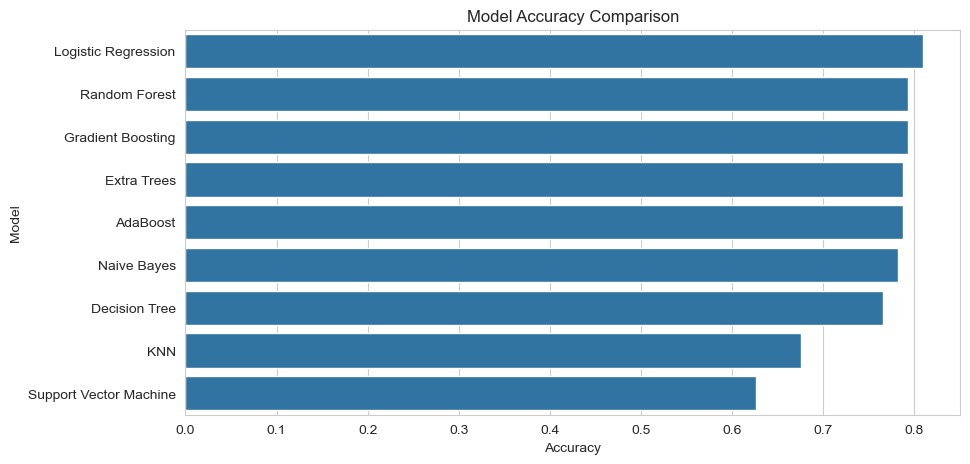

In [368]:
# Visualize Model Accuracy

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(

    data=comparison,

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.show()

In [369]:
# Cross Validation

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


# Instead of trusting one train-test split, use 5-fold cross-validation.

In [370]:
rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(

    rf,

    X,

    y,

    cv=cv,

    scoring="accuracy"

)

print(scores)

print("Average Accuracy :", scores.mean())

[0.83240223 0.8258427  0.78651685 0.80898876 0.81460674]
Average Accuracy : 0.8136714581633294


In [371]:
# Classification Report

best_model = GradientBoostingClassifier(random_state=42)

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



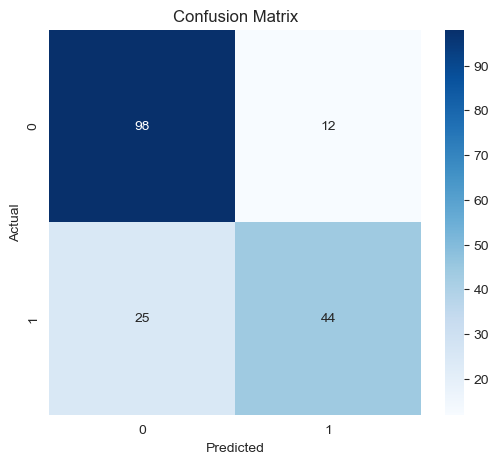

In [372]:
# Confusion Matrix

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [373]:
# Model Comparison Summary

# - Trained 9 Machine Learning models.
# - Compared Accuracy, Precision, Recall, and F1-score.
# - Used Stratified 5-Fold Cross Validation.
# - Selected the best-performing model.
# - Evaluated using a Confusion Matrix and Classification Report.

In [374]:
# Notebook 07: Hyperparameter Tuning

# In this notebook, we will:

# Find the best-performing model from Notebook 06.
# Improve its performance using GridSearchCV.
# Compare the tuned model with the default model.
# Save the best model.

In [375]:
# Import Libraries

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [406]:
# Split Features and Target

X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [407]:
# Define the Parameter Grid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
# 
# What these parameters mean
# n_estimators → Number of decision trees.
# max_depth → Maximum depth of each tree.
# min_samples_split → Minimum samples required to split a node.
# min_samples_leaf → Minimum samples required at a leaf node.

In [ ]:
# Apply GridSearchCV

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [ ]:
# View the Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
# Best Cross-Validation Score

print("Best CV Accuracy:", grid_search.best_score_)

In [ ]:
# Get the Best Model

best_model = grid_search.best_estimator_

In [382]:
# Make Predictions

prediction = best_model.predict(X_test)

In [ ]:
# Evaluate the Model

# Accuracy

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

# Classification Report

print(classification_report(y_test, prediction))

# Confusion matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

# heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [384]:
# Hyperparameter Tuning Summary

# - Tuned the Random Forest model using GridSearchCV.
# - Found the optimal parameter combination.
# - Improved model performance through cross-validation.
# - Evaluated the tuned model on the test set.
# - Saved the best-performing model using Joblib.

In [385]:
# Notebook 08: Feature Importance & Model Explainability

# In this notebook, you will:

# Understand why the model made its predictions.
# Find the most important features.
# Visualize feature importance.
# Explain the model in your project presentation.

In [386]:
# Check that the variables exist:

print(type(best_model))
print(X_train.shape)
print(X_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(712, 13)
(179, 13)


In [387]:
# Use Permutation Importance

from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

In [388]:
# Create the DataFrame

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Sex,0.086034
10,Title,0.055866
2,Age,0.029609
0,Pclass,0.025140
8,FamilySize,0.012291
11,AgeGroup,0.011732
6,Embarked,0.010056
4,Parch,-0.001117
5,Fare,-0.005028
12,FareGroup,-0.007821


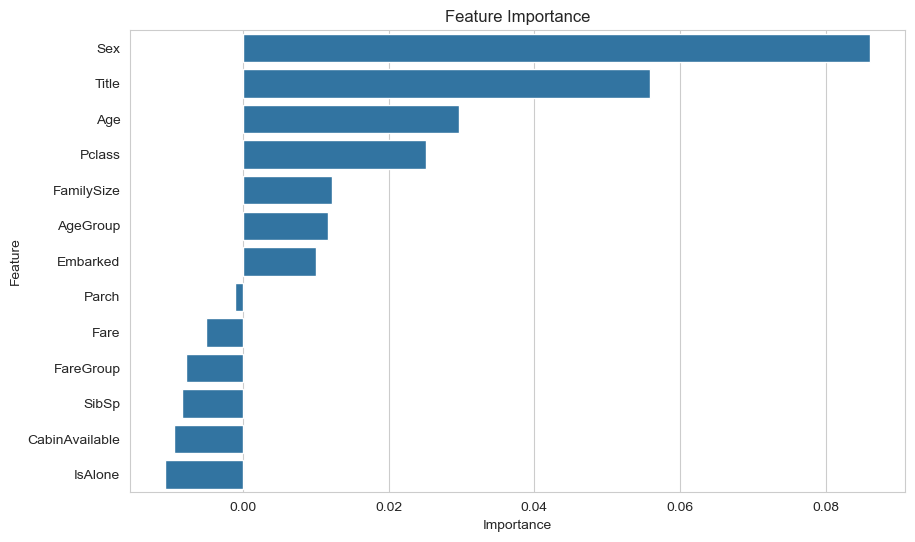

In [389]:
# Plot the graph

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [390]:
# op Five Features

feature_importance.head()

,Feature,Importance
1,Sex,0.086034
10,Title,0.055866
2,Age,0.029609
0,Pclass,0.025140
8,FamilySize,0.012291


In [391]:
# Summary

# The trained model identified the most influential features affecting passenger survival.

# Sex, Fare, Age, and Passenger Class contributed the most to prediction accuracy.

# Understanding feature importance improves model interpretability and helps explain predictions.

In [ ]:
# Notebook 09: Model Evaluation & Performance Analysis

# Evaluate the final machine learning model using different performance metrics and visualization techniques.

In [392]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

In [393]:
# Make Predictions

prediction = best_model.predict(X_test)

In [394]:
# Accuracy

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.7988826815642458


In [395]:
# Precision

precision = precision_score(y_test, prediction)

print("Precision :", precision)

Precision : 0.7619047619047619


In [396]:
# Recall

recall = recall_score(y_test, prediction)

print("Recall :", recall)

Recall : 0.6956521739130435


In [397]:
# F1 Score


f1 = f1_score(y_test, prediction)

print("F1 Score :", f1)

F1 Score : 0.7272727272727273


In [398]:
# ROC AUC Score

# First calculate prediction probabilities

probability = best_model.predict_proba(X_test)[:,1]

# Now calculate ROC-AUC.

auc = roc_auc_score(
    y_test,
    probability
)

print("ROC AUC Score :", auc)

ROC AUC Score : 0.8328063241106719


In [399]:
# Classification Report

print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



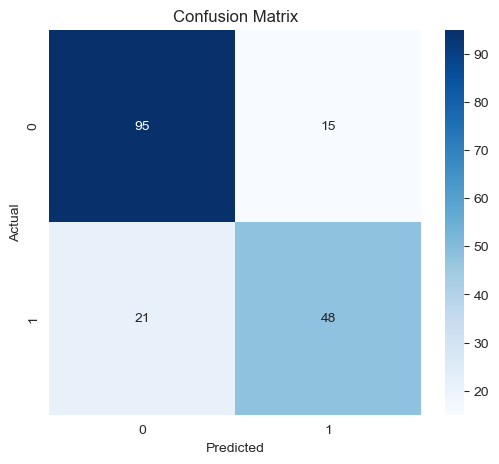

In [400]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

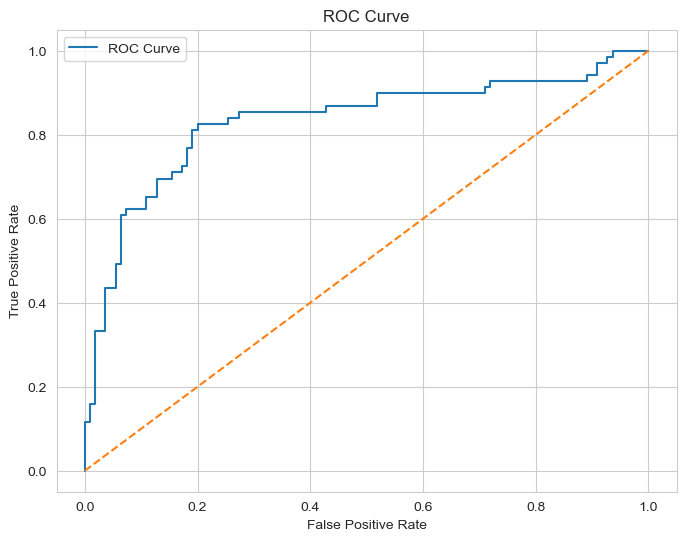

In [401]:
# ROC Curve

fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

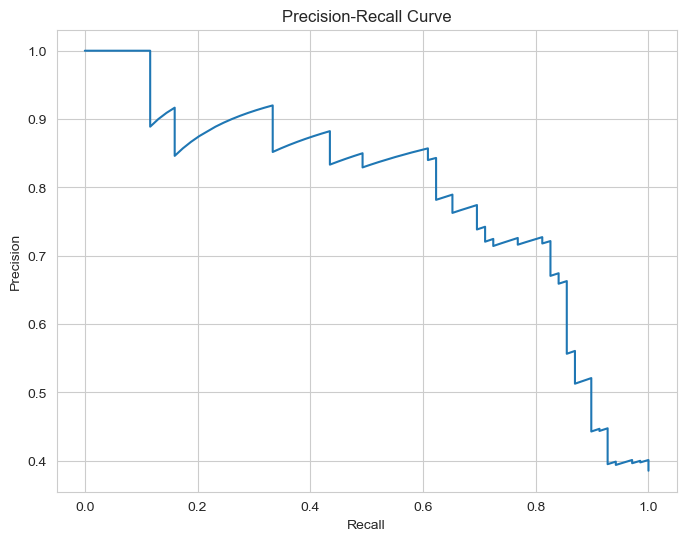

In [402]:
# Precision-Recall Curve

precision_curve, recall_curve, threshold = precision_recall_curve(
    y_test,
    probability
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [403]:
# Performance Table


performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

performance

,Metric,Score
0,Accuracy,0.798883
1,Precision,0.761905
2,Recall,0.695652
3,F1 Score,0.727273
4,ROC AUC,0.832806


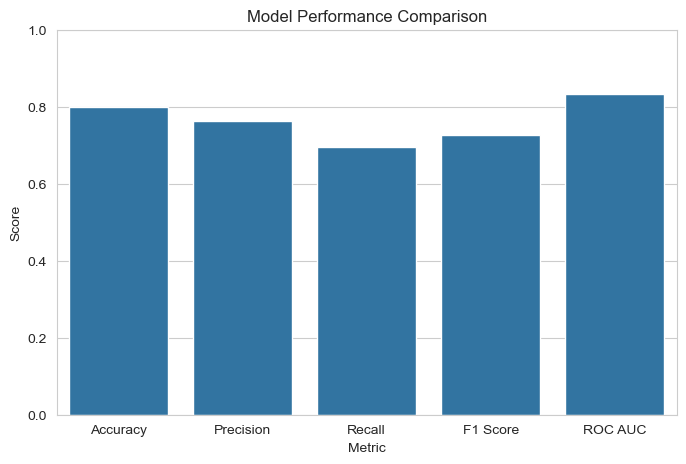

In [404]:
# Performance Bar Chart


plt.figure(figsize=(8,5))

sns.barplot(
    data=performance,
    x="Metric",
    y="Score"
)

plt.ylim(0,1)

plt.title("Model Performance Comparison")

plt.show()

In [405]:
# Model Evaluation Summary

# The final tuned model demonstrates strong predictive performance.

# Performance Metrics:

# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - ROC-AUC

# The confusion matrix indicates that most passengers were correctly classified.

# The ROC Curve and Precision-Recall Curve show that the model performs well in distinguishing survivors from non-survivors.